# Bank Marketing Classification Analysis

## Project Overview
This project applies machine learning classification models to predict whether 
a bank customer will subscribe to a term deposit based on demographic and 
campaign data. We compare five models to identify the best performer.

**Dataset Source:** UCI Machine Learning Repository - Bank Marketing Dataset  
**Records:** 41,188 customers | **Features:** 20 | **Target:** Subscription (yes/no)

## Analysis Plan

**Section 1: Data Loading and Exploration**
- 1.1 Import libraries
- 1.2 Load dataset
- 1.3 Basic exploration (shape, columns, first rows)

**Section 2: Exploratory Data Analysis (EDA)**
- 2.1 Missing values, duplicates, and data leakage
- 2.2 Class distribution
- 2.3 Numerical feature distributions
- 2.4 Categorical feature distributions

**Section 3: Data Preprocessing**
- 3.1 Encode categorical features
- 3.2 Train / validation / test split
- 3.3 Scale numerical features
- 3.4 Handle class imbalance (oversampling)

**Section 4: Classification Models**
- 4.1 k-Nearest Neighbors (kNN)
- 4.2 Naive Bayes
- 4.3 Logistic Regression
- 4.4 Support Vector Machine (SVM)
- 4.5 Neural Network (MLP)

**Section 5: Model Comparison and Recommendations**
- 5.1 Results summary table
- 5.2 Business recommendations

---

### 1.1 Import Libraries

We start by importing the core libraries needed for data loading and visualization.
Additional libraries for machine learning will be imported in later sections as needed.

- **pandas**: For data manipulation and analysis
- **numpy**: For numerical operations
- **matplotlib**: For creating visualizations

In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Load the Dataset

The dataset uses a **semicolon (`;`)** as the separator instead of a comma.
This is common in European datasets. We specify `sep=';'` to handle this correctly.

In [165]:
df = pd.read_csv('data/bank-additional-full.csv', sep=';')
print("Data loaded successfully!")

Data loaded successfully!


##1.3

### 1.3 Preview the Data

We check the dataset's shape, column names, and first few rows to understand 
what data we are working with before any cleaning or analysis.

In [166]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (41188, 21)

Columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Section 2: Exploratory Data Analysis (EDA)

Before any preprocessing, we explore the raw data to understand distributions, 
spot problems, and find patterns that will guide our modeling decisions.

### 2.1 Missing Values, Duplicates, and Data Leakage

We check data quality first, then remove the `duration` column before any 
analysis begins.

> **Why drop `duration`?** This column records the length of the last phone call 
> in seconds. It is only known after the call ends, meaning it would not be 
> available at prediction time in a real system. Including it would give the model 
> an unfair advantage and produce misleadingly high accuracy. This is called 
> **data leakage**: when information that would not be available in production 
> is used during training. The UCI dataset documentation explicitly warns about 
> this issue.

In [167]:
print('missing values in each column:')
print(df.isnull().sum())

missing values in each column:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [168]:
print("\nNumber of duplicate rows before dropping:", df.duplicated().sum())
df = df.drop_duplicates()
print("Number of duplicate rows after dropping:", df.duplicated().sum())
print("New shape:", df.shape)


Number of duplicate rows before dropping: 12
Number of duplicate rows after dropping: 0
New shape: (41176, 21)


We drop duration because it records the length of the phone call. This information is only known after the call ends, so it would not be available at the time of prediction. Keeping it would create data leakage and make the model unrealistically strong.

In [169]:
df.drop('duration', axis=1, inplace=True)
print("Column 'duration' dropped successfully!")

Column 'duration' dropped successfully!


### 2.2 Class Distribution

Before building any model, we check how balanced our target variable is. 
If one class has far more samples than the other, models tend to predict 
the majority class most of the time and still show high accuracy, which 
is misleading. This is called the **class imbalance problem**.

Class distribution:
y
no     36537
yes     4639
Name: count, dtype: int64

Class distribution (%):
y
no     88.733728
yes    11.266272
Name: proportion, dtype: float64


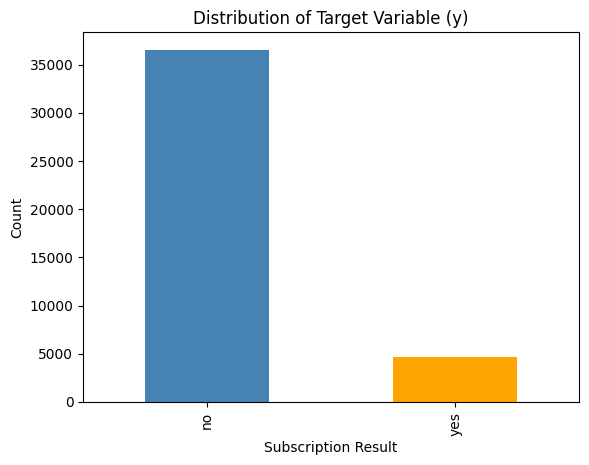

In [170]:
print("Class distribution:")
print(df['y'].value_counts())
print("\nClass distribution (%):")
print(df['y'].value_counts(normalize=True)*100)

df['y'].value_counts().plot(kind='bar', color=['steelblue', 'orange'])
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscription Result')
plt.ylabel('Count')
plt.show()

**Results:** The dataset is heavily imbalanced. Only 11.3% of customers subscribed 
to the term deposit while 88.7% did not. This means:

- A model that predicts "no" for every customer would still achieve 88.7% accuracy
- Accuracy alone is therefore a misleading metric for this problem
- We will use **precision, recall, and F1-score** to evaluate models properly
- We will apply **oversampling** during preprocessing to help models learn the 
  minority class better

### 2.3 Numerical Feature Distributions

We examine the distribution of each numerical feature to understand the range, 
spread, and shape of the data. This helps us identify skewed features, outliers, 
and whether scaling will be needed later.

In [171]:
print("Statistical summary of numerical columns:")
display(df.describe())

Statistical summary of numerical columns:


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41176.00000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000,41176.000000
mean,40.02380,2.567879,962.464810,0.173013,0.081922,93.575720,-40.502863,3.621293,5167.034870
std,10.42068,2.770318,186.937102,0.494964,1.570883,0.578839,4.627860,1.734437,72.251364
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


**Results:** The dataset has 9 numerical features. One important observation:

> **Note on `pdays`:** The value 999 means the customer was never contacted in 
> a previous campaign. It is not a real number but a code for "not applicable". 
> This explains why the mean is 962 and 75% of values are 999. This column 
> should be interpreted with caution during modeling.

### 2.3.1 Numerical Feature Distributions

We plot the distribution of each numerical feature to identify skewness, 
outliers, and unusual patterns in the data.

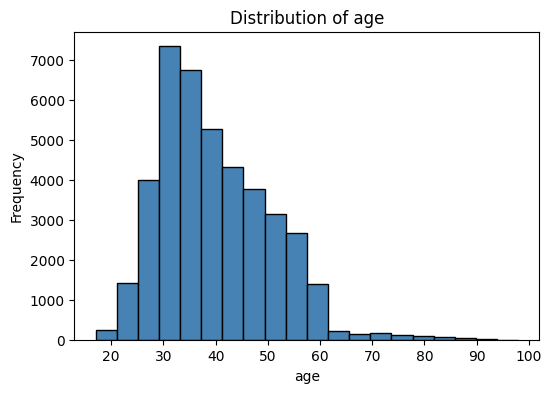

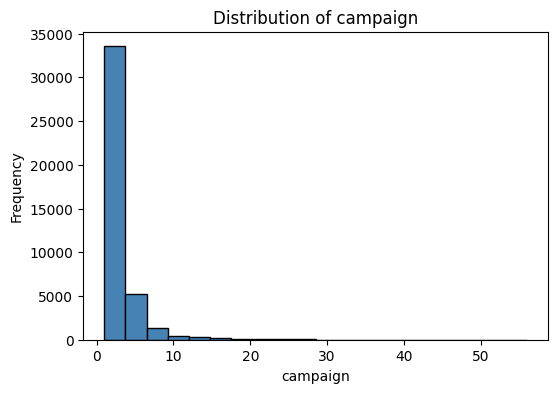

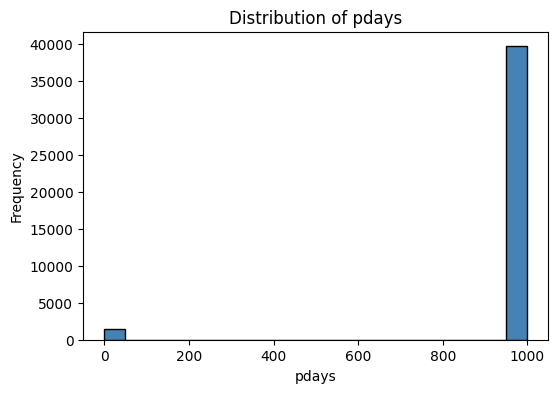

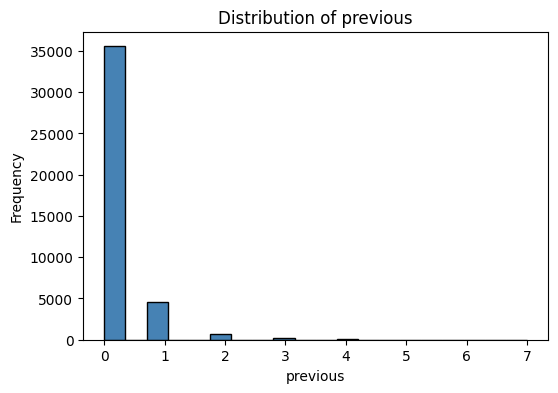

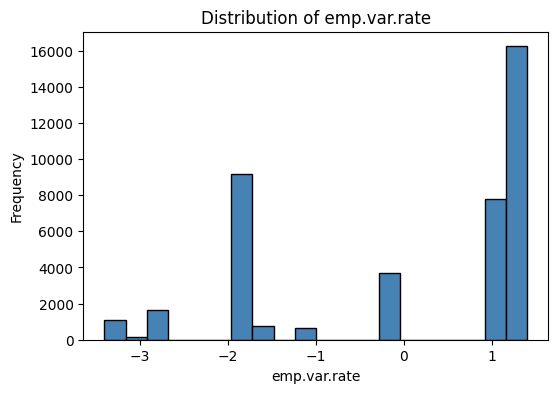

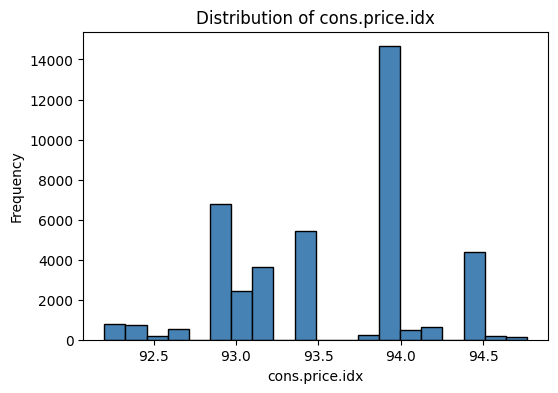

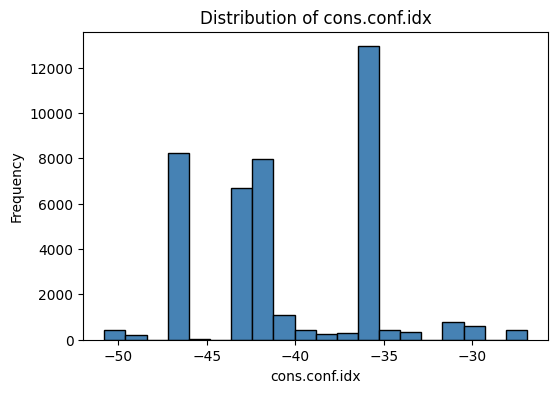

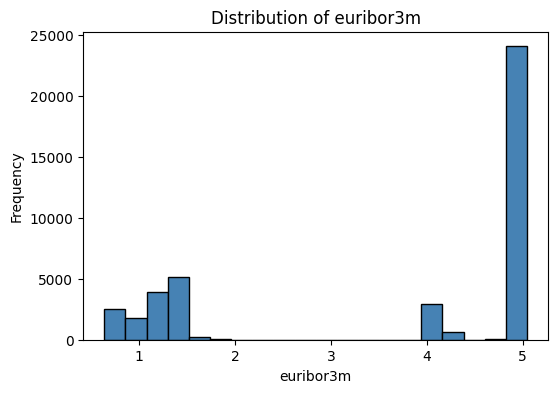

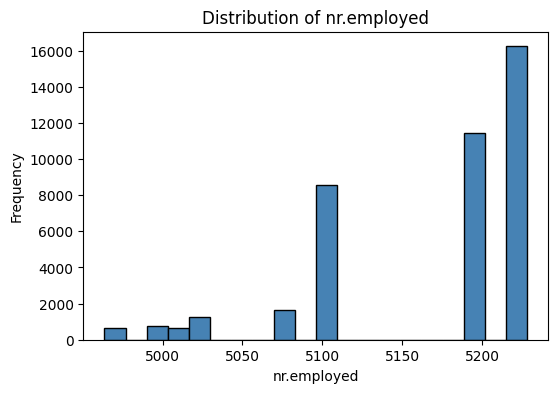

In [172]:
for col in df.describe().columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=20, color='steelblue', edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

**Results:** Two features stand out:

- **`pdays`**: The spike at 999 confirms that the vast majority of customers 
  were never contacted in a previous campaign. Only a small fraction have a 
  real pdays value.

- **`campaign`**: Heavily right-skewed. Most customers were contacted only 1 to 3 
  times during this campaign. A small number were contacted over 30 times, 
  which are likely outliers worth noting.

### 2.4 Categorical Feature Distributions

We examine the distribution of each categorical feature using count plots. 
This helps us understand the composition of our customer base and spot 
any categories with very few records.

In [173]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41176,41176,41176,41176,41176,41176,41176,41176,41176,41176,41176
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10419,24921,12164,32577,21571,33938,26135,13767,8618,35551,36537


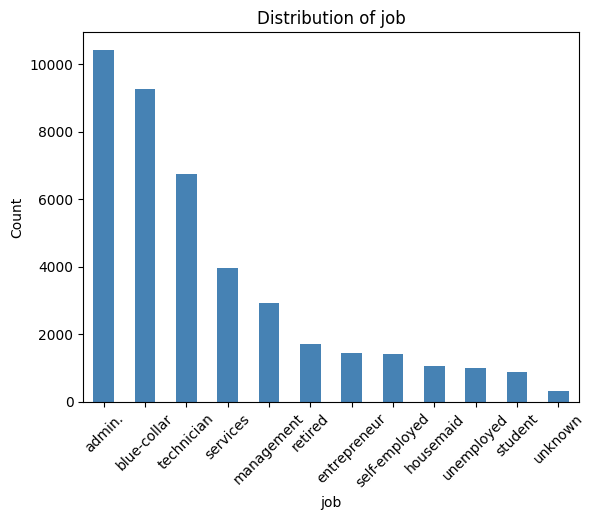

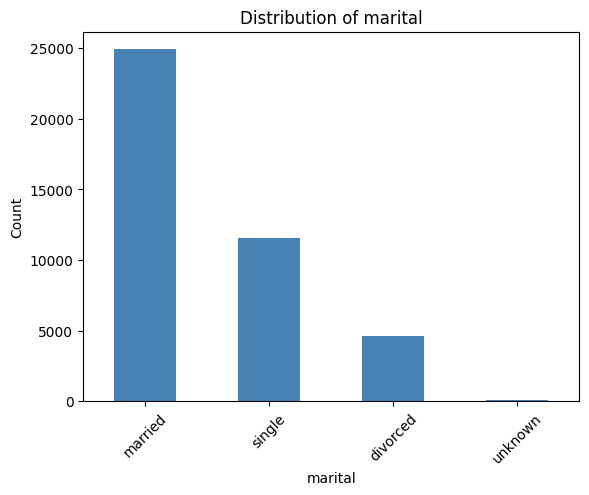

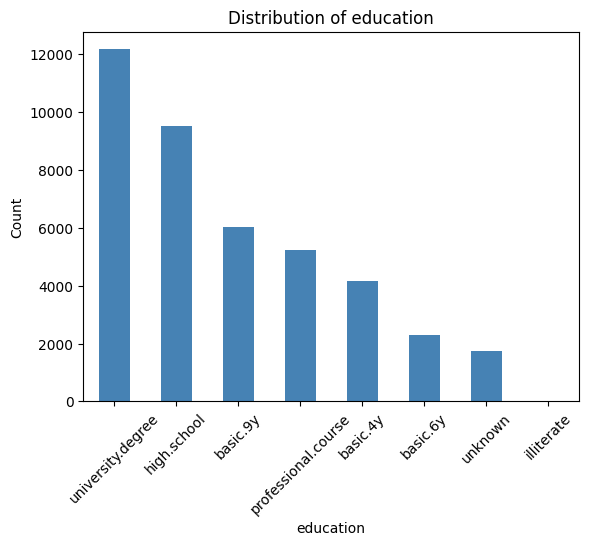

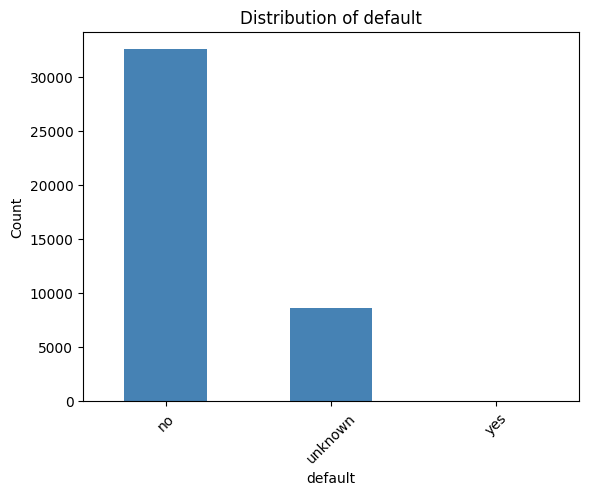

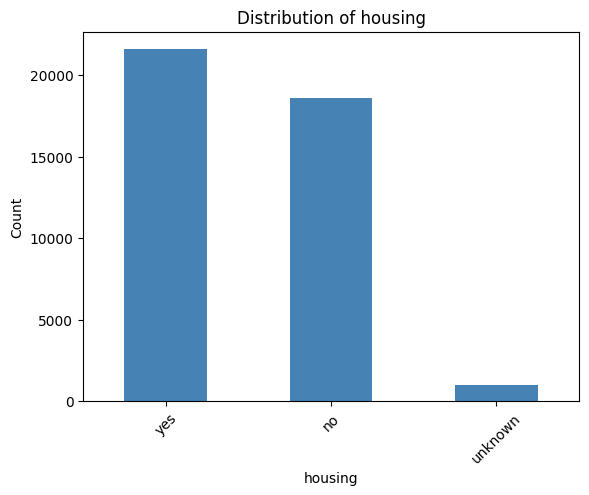

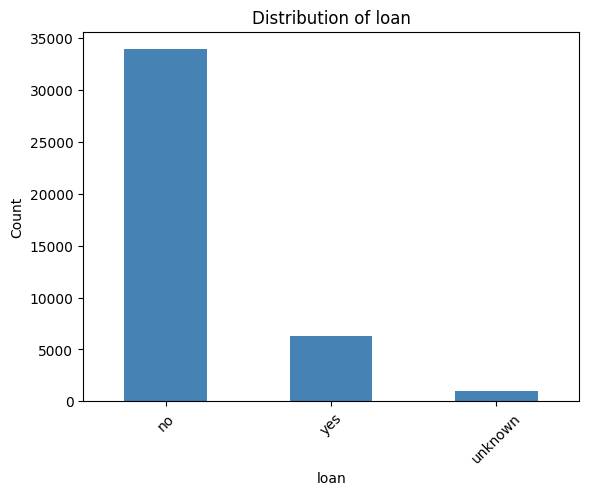

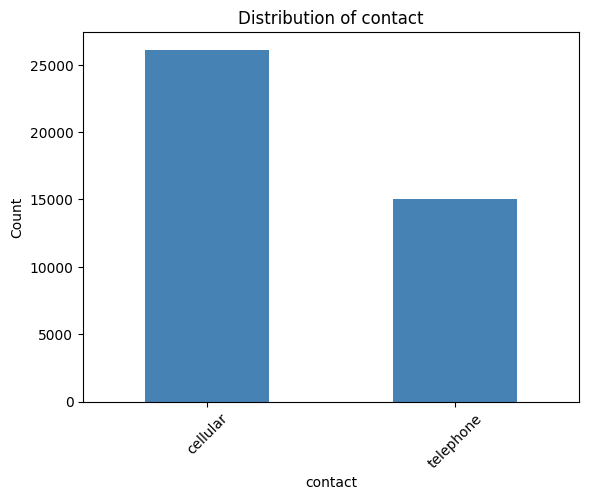

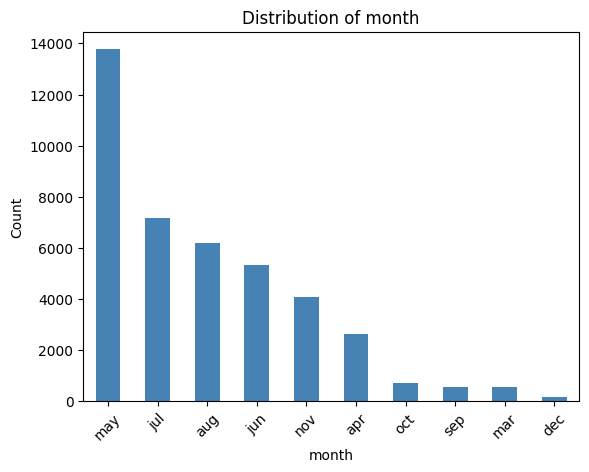

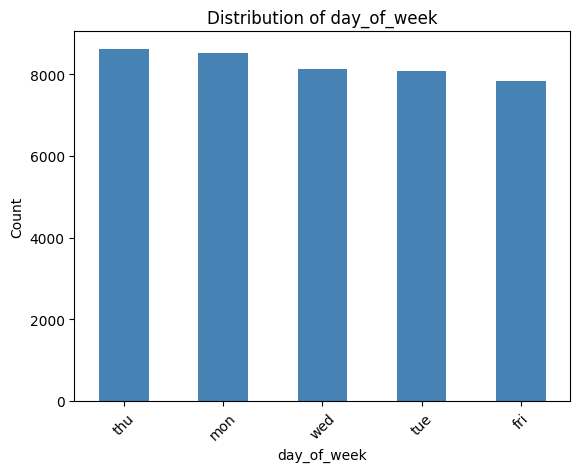

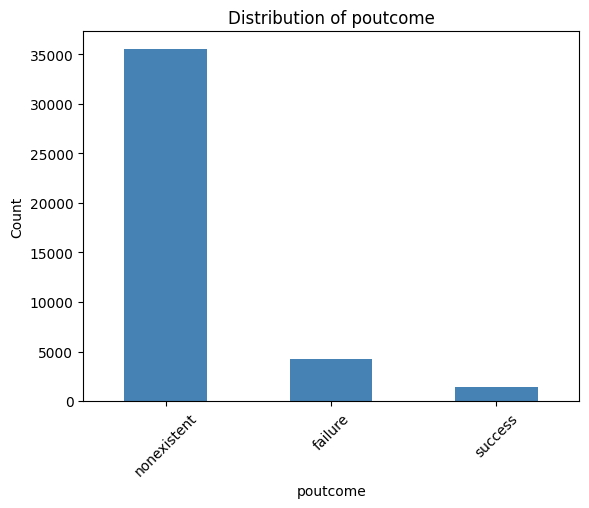

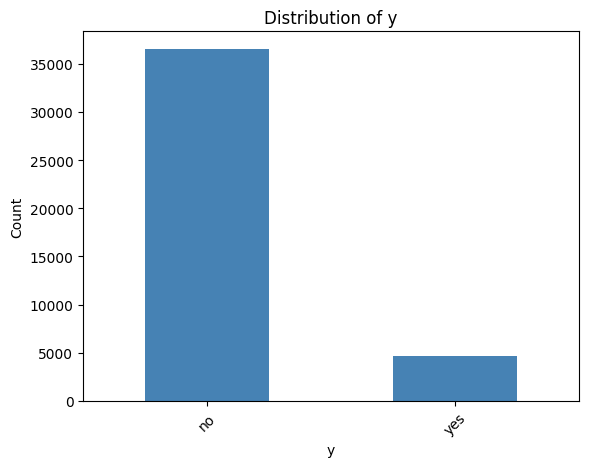

In [174]:
for col in df.describe(include='object').columns:
    df[col].value_counts().plot(kind='bar', color='steelblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

**Results:** Several important patterns in the categorical features:

- **`default`**: Almost no customers have credit in default (only 3 out of 41,176). 
  This feature will likely have no predictive power and could be dropped.
- **`poutcome`**: 86% of customers were never contacted in a previous campaign 
  (nonexistent), which aligns with what we saw in `pdays`.
- **`month`**: May dominates with 13,767 contacts, suggesting campaigns are 
  heavily concentrated in certain months.
- **`day_of_week`**: Very evenly distributed across all weekdays, so this feature 
  likely adds little predictive value.
- **`education`**: University degree is the most common, but illiterate has only 
  18 records which is very small and may cause issues during modeling.
- **`y`**: Confirms our earlier finding of heavy class imbalance (89% no, 11% yes).

### 2.5 Dropping Low-Value Features

The `default` column has only 3 "yes" values out of 41,176 records. This means 
it carries almost no predictive signal and could cause issues during modeling. 
We drop it before preprocessing.

In [175]:
df.drop('default', axis=1, inplace=True)
print("'default' column dropped.")
print("New shape:", df.shape)

'default' column dropped.
New shape: (41176, 19)


### Handling Special Values in `pdays`

The variable `pdays` represents the number of days since the client was last contacted in a previous campaign.

A value of `999` does not represent an actual number of days. Instead, it indicates that the client was **not previously contacted**.

To handle this correctly:
- We create a new binary feature indicating whether the client was contacted before
- We replace the value `999` with `0` in the `pdays` column

This allows the model to distinguish between:
- Clients who were never contacted before  
- Clients who were contacted recently or in the past

In [176]:
# Create binary feature: whether the client was contacted before
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)

# Replace 999 with 0 in pdays
df['pdays'] = df['pdays'].replace(999, 0)

print("Feature 'was_contacted_before' created and 'pdays' cleaned successfully!\n")

# Quick check
print(df[['pdays', 'was_contacted_before']].head())

Feature 'was_contacted_before' created and 'pdays' cleaned successfully!

   pdays  was_contacted_before
0      0                     0
1      0                     0
2      0                     0
3      0                     0
4      0                     0


## Section 3 - Preprocessing for Machine Learning

Before building machine learning models, we need to prepare the dataset in a format that algorithms can understand and work with effectively.

In the previous sections, we explored and cleaned the data. Now, we move from analysis to modeling.

Most machine learning models:
- Cannot work with text (categorical variables) directly  
- Require numerical input features  
- Are sensitive to how data is structured and prepared  

If we skip proper preprocessing:
- The model may fail to run  
- Results may be inaccurate or misleading  
- We risk introducing errors such as data leakage  

In this section, we will:
- Convert the target variable into numeric format  
- Separate features and target variables  
- Identify numerical and categorical columns  
- Split the data into training and testing sets  
- Prepare the data for modeling using a structured approach  

This step is essential to ensure that our models are accurate, reliable, and generalizable to new data.

### 3.1 Encoding the Target Variable

The target variable `y` currently contains text values:
- `yes` → customer subscribed  
- `no` → customer did not subscribe  

Machine learning models require the target variable to be in numeric format.  
We convert:
- `yes` → 1  
- `no` → 0  

This allows us to treat the problem as a **binary classification task**, where the model predicts either 0 or 1.

After encoding, we will verify that the transformation was successful by checking the distribution of the target variable.

In [177]:
# Encode target variable
df['y'] = df['y'].map({'yes': 1, 'no': 0})

print("Target variable 'y' encoded successfully!\n")

# Verify encoding
print("Target distribution (counts):")
print(df['y'].value_counts())

print("\nTarget distribution (%):")
print(df['y'].value_counts(normalize=True).round(3))

Target variable 'y' encoded successfully!

Target distribution (counts):
y
0    36537
1     4639
Name: count, dtype: int64

Target distribution (%):
y
0    0.887
1    0.113
Name: proportion, dtype: float64


### 3.2 Separating Features and Target

In machine learning, we separate the dataset into:

- **Features (X)** → the input variables used to make predictions  
- **Target (y)** → the variable we are trying to predict  

This separation is a standard step before training any model.

The features will include all columns except the target variable, while `y` will contain only the encoded target values.

After separating them, we will check their shapes to confirm everything is structured correctly.

In [178]:
# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFirst 5 rows of features:")
display(X.head())

Features (X) shape: (41176, 19)
Target (y) shape: (41176,)

First 5 rows of features:


,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before
0,56,housemaid,married,basic.4y,no,no,telephone,may,mon,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,no,no,telephone,may,mon,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,yes,no,telephone,may,mon,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,telephone,may,mon,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,yes,telephone,may,mon,1,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


### 3.3 Identifying Numerical and Categorical Features

Our dataset contains two main types of variables:

### Numerical Features
These are quantitative variables that represent measurable values, such as:
- age
- campaign
- pdays (cleaned)
- previous
- was_contacted_before
- emp.var.rate
- cons.price.idx
- cons.conf.idx
- euribor3m
- nr.employed

### Categorical Features
These are variables that represent categories or groups, such as:
- job
- marital
- education
- housing
- loan
- contact
- month
- day_of_week
- poutcome

Machine learning models cannot directly work with categorical variables, so we will need to encode them later.

Separating numerical and categorical features at this stage allows us to apply the correct preprocessing techniques to each group in a structured way.

Note: The Bank Marketing dataset has multiple versions. This version includes additional macroeconomic features and does not contain the `balance` column.

In [179]:
df.describe(include='object')

,job,marital,education,housing,loan,contact,month,day_of_week,poutcome
count,41176,41176,41176,41176,41176,41176,41176,41176,41176
unique,12,4,8,3,3,2,10,5,3
top,admin.,married,university.degree,yes,no,cellular,may,thu,nonexistent
freq,10419,24921,12164,21571,33938,26135,13767,8618,35551


In [180]:
# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before']

Categorical columns:
['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


### 3.4 Train-Test Split

Before building a machine learning model, we split the dataset into two parts:

- **Training set** → used to train the model  
- **Testing set** → used to evaluate the model on unseen data  

We typically use:
- 80% of the data for training  
- 20% for testing  

This helps us measure how well the model generalizes to new data and prevents overfitting.

Since this dataset is imbalanced, we use stratified sampling to ensure that the proportion of subscribed and non-subscribed customers is preserved in both training and testing sets.

At this stage, we only split the data.  
Preprocessing steps such as encoding will be applied later using a structured pipeline.

In [181]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print("Data split into training and testing sets successfully!\n")

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Data split into training and testing sets successfully!

X_train shape: (32940, 19)
X_test shape: (8236, 19)
y_train shape: (32940,)
y_test shape: (8236,)


### 3.5 Preprocessing Categorical and Numerical Features

Our dataset contains both numerical and categorical variables, and each type needs to be handled differently before modeling.

- Numerical features may have different ranges, so scaling helps some machine learning models perform better.
- Categorical features must be converted into numerical format because machine learning algorithms cannot work with text values directly.

To handle this in a clean and consistent way, we use a preprocessing pipeline.

In this project:
- Numerical features will be scaled using StandardScaler
- Categorical features will be transformed using One-Hot Encoding

We use a ColumnTransformer to apply these transformations to the appropriate columns in a single step.

Some categorical variables contain the value `unknown`, which represents missing or unreported information. We keep `unknown` as a separate category so the model can learn whether missing information itself is useful for prediction.

This structured approach helps us:
- Apply transformations consistently
- Avoid data leakage
- Prepare training and testing data in the same way

#### 3.5.1 Scaling Numerical Features

Numerical features may have different ranges. Scaling ensures that all numerical variables are on a similar scale, which helps models such as Logistic Regression perform better.

We use StandardScaler to standardize numerical features.

In [184]:
from sklearn.preprocessing import StandardScaler

# Define scaler for numerical features
num_transformer = StandardScaler()

print("Numerical transformer (StandardScaler) defined.")

Numerical transformer (StandardScaler) defined.


#### 3.5.2 Encoding Categorical Features

Categorical features must be converted into numerical format before modeling.

We use One-Hot Encoding to transform each category into a binary column. For example, a variable such as `job` will be expanded into multiple columns representing each category.

We use the parameter `handle_unknown='ignore'` to ensure that the model can handle categories that may appear in the testing data but were not seen during training. Without this, the model could raise an error when encountering new categories.

We keep all categories (instead of dropping one) to make the output easier to interpret and to support different types of machine learning models.

In [185]:
from sklearn.preprocessing import OneHotEncoder

# Define encoder for categorical features
cat_transformer = OneHotEncoder(handle_unknown='ignore')

print("Categorical transformer (OneHotEncoder) defined.")

Categorical transformer (OneHotEncoder) defined.


#### 3.5.3 Combining Preprocessing Steps

To apply different transformations to numerical and categorical features in a consistent way, we use a ColumnTransformer.

This allows us to:
- Apply scaling to numerical features  
- Apply encoding to categorical features  
- Combine everything into a single preprocessing step  

In [186]:
from sklearn.compose import ColumnTransformer

# Combine numerical and categorical transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ]
)

print("Preprocessing pipeline (ColumnTransformer) created successfully!")

Preprocessing pipeline (ColumnTransformer) created successfully!


### Summary of Preprocessing Steps

In this section, we prepared the dataset for machine learning by defining the necessary preprocessing steps.

We:
- Identified numerical and categorical features  
- Defined scaling for numerical features using StandardScaler  
- Defined encoding for categorical features using One-Hot Encoding  
- Combined these transformations using a ColumnTransformer  

At this stage, no transformations have been applied yet. The preprocessing steps have only been defined and will be applied later as part of a machine learning pipeline.

This approach ensures that all transformations are applied consistently and helps prevent data leakage.

## Section 4 - Machine Learning Models

In this section, we build and evaluate machine learning models to predict whether a client will subscribe to a term deposit.

We combine preprocessing and model training using pipelines to ensure a clean and consistent workflow.

We start with Logistic Regression as a baseline model and will extend the analysis to other models for comparison.

### What is a Pipeline?

A pipeline is a way to combine multiple steps such as preprocessing and model training into a single workflow.

Instead of applying transformations manually, the pipeline:
- Applies preprocessing to the data  
- Trains the model on the processed data  

When we call `fit()` on the pipeline:
- It learns transformations using the training data  
- Then trains the model  

When we call `predict()`:
- It applies the same transformations to new data  
- Then makes predictions  

This ensures that:
- Preprocessing is applied consistently  
- There is no data leakage  
- The workflow is clean and easy to manage

### 4.1 Logistic Regression

We start with Logistic Regression as a simple and interpretable baseline model.

We will:
- Create a pipeline that includes preprocessing and the model  
- Train the model on the training data  
- Evaluate its performance on the test data

#### 4.1.1 Creating the Pipeline

We combine the preprocessing steps and the Logistic Regression model into a single pipeline.

This ensures that preprocessing is applied automatically during both training and prediction.

In [193]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Create pipeline
log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

print("Pipeline with Logistic Regression created successfully!")

Pipeline with Logistic Regression created successfully!


#### 4.1.2 Training the Model

We now train the pipeline using the training data.

This step applies preprocessing and fits the model in a single operation.

In [194]:
# Train the pipeline (includes preprocessing + model)
log_pipeline.fit(X_train, y_train)

print("Pipeline trained successfully!")

Pipeline trained successfully!


#### 4.1.3 Evaluating the Model

After training, we evaluate the model using the test data.

We generate predictions and assess model performance using appropriate evaluation metrics.

We also use a confusion matrix to understand how many predictions were correct and where the model makes errors.

In [195]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = log_pipeline.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7308
           1       0.65      0.21      0.32       928

    accuracy                           0.90      8236
   macro avg       0.78      0.60      0.63      8236
weighted avg       0.88      0.90      0.87      8236

Confusion Matrix:
[[7205  103]
 [ 733  195]]


### Model Interpretation

The model achieves high overall accuracy (90%), but this is mainly driven by its strong performance on the majority class (customers who do not subscribe).

For the minority class (customers who subscribe), the model performs poorly:
- Recall is only 0.21, meaning the model identifies only 21% of actual subscribers  
- A large number of subscribers are incorrectly classified as non-subscribers  

The confusion matrix confirms this issue:
- 733 actual subscribers were missed (false negatives)  
- Only 195 subscribers were correctly identified  

This indicates that the model is biased toward predicting the majority class and is not effective at identifying potential customers who are likely to subscribe.

In a business context, this is a critical limitation, as missing potential subscribers means lost opportunities for the marketing campaign.

We identified class imbalance during EDA, but we first trained a baseline model without adjustments. This allows us to clearly observe the impact of imbalance before applying corrective techniques.

#### Improving Logistic Regression for Imbalanced Data

The dataset is imbalanced, with far fewer customers subscribing compared to those who do not.

To address this, we adjust the model using `class_weight='balanced'`. This increases the importance of the minority class during training and helps the model better identify potential subscribers.

In [199]:
# Create pipeline with balanced class weights
log_pipeline_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

print("Balanced Logistic Regression pipeline created successfully!\n")

# Train
log_pipeline_balanced.fit(X_train, y_train)
print("Balanced pipeline trained successfully!\n")

# Predict
y_pred_balanced = log_pipeline_balanced.predict(X_test)

# Evaluate
print("Classification Report (Balanced Logistic Regression):\n")
print(classification_report(y_test, y_pred_balanced, target_names=['No', 'Yes']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

Balanced Logistic Regression pipeline created successfully!

Balanced pipeline trained successfully!

Classification Report (Balanced Logistic Regression):

              precision    recall  f1-score   support

          No       0.95      0.86      0.90      7308
         Yes       0.36      0.64      0.46       928

    accuracy                           0.83      8236
   macro avg       0.66      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236


Confusion Matrix:
[[6252 1056]
 [ 330  598]]


#### Interpretation of Balanced Logistic Regression

Using class_weight='balanced' significantly improves the model’s ability to detect subscribers.

- Recall for the "Yes" class increased from 0.21 to 0.64  
- The number of missed subscribers (false negatives) dropped from 733 to 330  

However, this comes with a trade-off:
- False positives increased substantially  
- Precision for the "Yes" class decreased  

This means the model is more aggressive in predicting potential subscribers, but at the cost of contacting more customers who may not subscribe.

In a business context, this trade-off can be acceptable. Marketing campaigns often prefer identifying more potential customers, even if it includes some false positives, rather than missing a large number of true subscribers.

### 4.2 Decision Tree

Next, we use a Decision Tree classifier.

Unlike Logistic Regression, Decision Trees can capture non-linear relationships and interactions between features. This makes them a useful model for comparison.

As before, we will:
- Create a pipeline that includes preprocessing and the model  
- Train the model on the training data  
- Evaluate its performance on the test data  

#### 4.2.1 Creating the Pipeline

We combine the preprocessing steps and the Decision Tree model into a single pipeline.

This keeps the workflow consistent and ensures that preprocessing is applied automatically during training and prediction.

In [200]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Create Decision Tree pipeline
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

print("Decision Tree pipeline created successfully!")

Decision Tree pipeline created successfully!


#### 4.2.2 Training and Evaluating the Model

We train the Decision Tree pipeline using the training data and then evaluate its performance on the test data.

This step applies preprocessing and fits the model in a single operation. After training, we generate predictions and assess performance using a classification report and confusion matrix.

This allows us to compare the Decision Tree model with previous models and understand its strengths and limitations.

In [201]:
# Train the Decision Tree pipeline
dt_pipeline.fit(X_train, y_train)
print("Decision Tree pipeline trained successfully!\n")

# Make predictions
y_pred_dt = dt_pipeline.predict(X_test)

# Evaluate
print("Classification Report (Decision Tree):\n")
print(classification_report(y_test, y_pred_dt, target_names=['No', 'Yes']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree pipeline trained successfully!

Classification Report (Decision Tree):

              precision    recall  f1-score   support

          No       0.92      0.91      0.91      7308
         Yes       0.32      0.35      0.34       928

    accuracy                           0.84      8236
   macro avg       0.62      0.63      0.62      8236
weighted avg       0.85      0.84      0.85      8236


Confusion Matrix:
[[6616  692]
 [ 601  327]]


#### Interpretation of Decision Tree Results

The Decision Tree model improves the detection of subscribers compared to the baseline Logistic Regression model, increasing recall for the "Yes" class from 0.21 to 0.35.

However, it still performs worse than the balanced Logistic Regression model, which achieved a recall of 0.64.

The model continues to struggle with identifying the minority class, missing a significant number of actual subscribers.

Compared to the balanced model, the Decision Tree produces fewer false positives but also identifies fewer true subscribers.

This highlights the trade-off between precision and recall and shows that while Decision Trees can capture non-linear patterns, they do not fully address the class imbalance issue on their own.

#### Improving Decision Tree for Imbalanced Data

As with Logistic Regression, we also test a balanced version of the Decision Tree model.

By using `class_weight='balanced'`, the model gives more importance to the minority class during training. This helps us evaluate whether balancing improves the model’s ability to identify subscribers.

In [202]:
# Create balanced Decision Tree pipeline
dt_pipeline_balanced = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced'))
])

print("Balanced Decision Tree pipeline created successfully!\n")

# Train
dt_pipeline_balanced.fit(X_train, y_train)
print("Balanced Decision Tree pipeline trained successfully!\n")

# Predict
y_pred_dt_balanced = dt_pipeline_balanced.predict(X_test)

# Evaluate
print("Classification Report (Balanced Decision Tree):\n")
print(classification_report(y_test, y_pred_dt_balanced, target_names=['No', 'Yes']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_balanced))

Balanced Decision Tree pipeline created successfully!

Balanced Decision Tree pipeline trained successfully!

Classification Report (Balanced Decision Tree):

              precision    recall  f1-score   support

          No       0.92      0.91      0.91      7308
         Yes       0.33      0.35      0.34       928

    accuracy                           0.85      8236
   macro avg       0.62      0.63      0.62      8236
weighted avg       0.85      0.85      0.85      8236


Confusion Matrix:
[[6650  658]
 [ 607  321]]


#### Interpretation of Balanced Decision Tree Results

Applying class_weight='balanced' to the Decision Tree model does not significantly improve performance.

- Recall for the "Yes" class remains around 0.35  
- The number of correctly identified subscribers changes only slightly  

This contrasts with Logistic Regression, where balancing had a large impact.

The reason is that Decision Trees are less sensitive to class imbalance, as they split data based on feature purity rather than optimizing a global objective function.

This result shows that balancing techniques do not have the same effect across all models and highlights the importance of testing model-specific behavior.